# Bloque de Machine Learning
### Predicción del precio de viviendas en Madrid (transformado a logaritmo) (`rent_price`)

En este notebook aplicamos dos modelos de Machine Learning supervisado para predecir el precio de compra de viviendas:  
- **Random Forest Regressor**
- **XGBoost Regressor**

Los datos ya vienen limpios y divididos en tres conjuntos: entrenamiento, validación y test.

---
## 1. Instalación e importación de librerías

In [22]:
#Importamos las librerías necesarias:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

---
## 2. Carga de datos

Cargamos los tres conjuntos ya preparados: entrenamiento (`train`), validación (`val`) y test (`test`).  
La división previa nos permite entrenar, ajustar hiperparámetros y evaluar de forma independiente y sin fuga de información.

In [23]:
# Cargamos los datos al notebook:
train = pd.read_csv("../03_datasets/train_data_prepared.csv")
val   = pd.read_csv("../03_datasets/val_data_prepared.csv")
test  = pd.read_csv("../03_datasets/test_data_prepared.csv")


# Sanity check
print("Train shape:", train.shape)
print("Val shape:  ", val.shape)
print("Test shape: ", test.shape)

print("Train dTypes:", train.dtypes)
print("\n Train nulls:", train.isnull().sum())
print("\n Val nulls:", val.isnull().sum())
print("\n Test nulls:", test.isnull().sum())
print("\n Train head:", train.head())


Train shape: (11454, 18)
Val shape:   (3757, 18)
Test shape:  (3707, 18)
Train dTypes: te__subtitle                   float64
te__Distrito                   float64
oh__house_type_id_Dúplex       float64
oh__house_type_id_Pisos        float64
oh__house_type_id_Áticos       float64
oh__is_floor_under_True        float64
oh__is_renewal_needed_True     float64
oh__is_new_development_True    float64
oh__has_lift_True              float64
oh__is_exterior_True           float64
oh__has_parking_True           float64
oe__energy_certificate         float64
ss__sq_mt_built                float64
ss__n_rooms                    float64
ss__n_bathrooms                float64
ss__floor                      float64
buy_price_log                  float64
rent_price                       int64
dtype: object

 Train nulls: te__subtitle                   0
te__Distrito                   0
oh__house_type_id_Dúplex       0
oh__house_type_id_Pisos        0
oh__house_type_id_Áticos       0
oh__is_floor_unde

In [24]:
pd.set_option('display.max_columns', None)

In [25]:
train.head()

,te__subtitle,te__Distrito,oh__house_type_id_Dúplex,oh__house_type_id_Pisos,oh__house_type_id_Áticos,oh__is_floor_under_True,oh__is_renewal_needed_True,oh__is_new_development_True,oh__has_lift_True,oh__is_exterior_True,oh__has_parking_True,oe__energy_certificate,ss__sq_mt_built,ss__n_rooms,ss__n_bathrooms,ss__floor,buy_price_log,rent_price
0,13.391121,13.066050,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,7.0,0.590918,0.228923,0.278005,-0.570332,13.228525,1795
1,12.339557,12.666359,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,7.0,-0.520380,0.228923,0.278005,1.695880,12.672950,1248
2,13.237534,13.266226,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,-0.591618,-0.592274,-0.806924,-0.570332,13.102163,1644
3,13.434851,13.259593,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,7.0,2.257867,2.692513,3.532793,-1.476817,13.284484,1869
4,12.981935,13.245381,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,7.0,-0.819576,-0.592274,-0.806924,2.149122,12.650762,1230


---
## 3. Separación de features y variable objetivo

Separamos cada conjunto en **X** (variables predictoras) e **y** (variable objetivo: `rent_price`).  
Esta separación es imprescindible antes de entrenar cualquier modelo.

In [26]:
# se generan los targets para los distintos datasets:
TARGET = "rent_price"

# Añadimos el alquiler a la lista de columnas prohibidas (Data Leakage)
columnas_prohibidas = ["buy_price_log", TARGET]

# Separamos features (X) y target (y) borrando las dos columnas prohibidas
X_train = train.drop(columns=columnas_prohibidas)
y_train = train[TARGET]

X_val   = val.drop(columns=columnas_prohibidas)
y_val   = val[TARGET]

X_test  = test.drop(columns=columnas_prohibidas)
y_test  = test[TARGET]

print(f'Features de entrenamiento: {X_train.shape}')
print(f'Features de validación:    {X_val.shape}')
print(f'Features de test:          {X_test.shape}')
print(f'\nNúmero de variables predictoras: {X_train.shape[1]}') # Ahora debería haber una menos que antes

Features de entrenamiento: (11454, 16)
Features de validación:    (3757, 16)
Features de test:          (3707, 16)

Número de variables predictoras: 16


# Modelo de Renta

---
## 5. Entrenamiento con hiperparámetros por defecto (baseline)

Antes de optimizar, entrenamos ambos modelos con su configuración por defecto.  
Esto nos da una **línea base** con la que comparar si el tuning realmente mejora los resultados.

### RandomForest (Baseline)

In [27]:
# --- Random Forest con parámetros por defecto ---
# random_state=42 garantiza reproducibilidad
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

print('✅ Random Forest (baseline) entrenado')

✅ Random Forest (baseline) entrenado


### XGBoost (Baseline)

In [28]:
# --- XGBoost con parámetros por defecto ---
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
xgb_base.fit(X_train, y_train)

print('✅ XGBoost (baseline) entrenado')

✅ XGBoost (baseline) entrenado


---
## 6. Evaluación en el conjunto de validación (baseline)

Evaluamos ambos modelos en el conjunto de **validación** usando tres métricas estándar de regresión:
- **MAE** (Error Absoluto Medio): error promedio en euros.
- **RMSE** (Raíz del Error Cuadrático Medio): penaliza más los errores grandes.
- **R²** (Coeficiente de determinación): proporción de varianza explicada (1.0 = perfecto)

In [29]:
def evaluar_modelo(nombre, modelo, X, y):
    """Calcula y muestra MAE, RMSE y R² para un modelo dado."""
    preds = modelo.predict(X)
    
    # --- AÑADIMOS ESTO: Pasamos de logaritmo a euros reales ---
    # --------------

    mae   = mean_absolute_error(y, preds)
    rmse  = np.sqrt(mean_squared_error(y, preds))
    r2    = r2_score(y, preds)

    print(f'\n=== {nombre} ===')
    print(f'  MAE:  {mae:,.4f} €')
    print(f'  RMSE: {rmse:,.4f} €')
    print(f'  R²:   {r2:.6f}')

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    

# Evaluamos los modelos baseline en validación
print('📊 Resultados en VALIDACIÓN (baseline):')
metricas_rf_base  = evaluar_modelo('Random Forest (baseline)', rf_base,  X_val, y_val)
metricas_xgb_base = evaluar_modelo('XGBoost (baseline)',       xgb_base, X_val, y_val)

📊 Resultados en VALIDACIÓN (baseline):

=== Random Forest (baseline) ===
  MAE:  152.1096 €
  RMSE: 248.5329 €
  R²:   0.822939

=== XGBoost (baseline) ===
  MAE:  159.1496 €
  RMSE: 262.8366 €
  R²:   0.801972


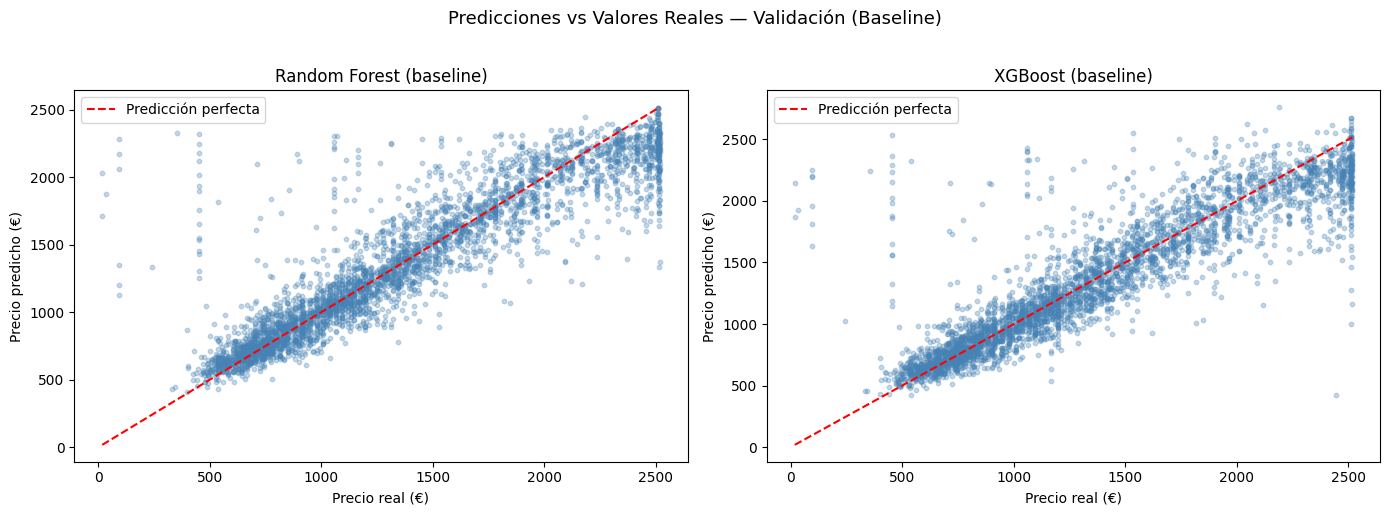

In [30]:
# Visualización: predicciones vs valores reales (baseline)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, modelo, nombre in zip(axes,
                               [rf_base, xgb_base],
                               ['Random Forest (baseline)', 'XGBoost (baseline)']):
    preds = modelo.predict(X_val)
    ax.scatter(y_val, preds, alpha=0.3, s=10, color='steelblue')
    # Línea perfecta de referencia
    lims = [y_val.min(), y_val.max()]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Precio real (€)')
    ax.set_ylabel('Precio predicho (€)')
    ax.set_title(nombre)
    ax.legend()

plt.suptitle('Predicciones vs Valores Reales — Validación (Baseline)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Optimización de hiperparámetros con RandomizedSearchCV

Usamos `RandomizedSearchCV` en lugar de `GridSearchCV` porque:
- Explora combinaciones **aleatorias** del espacio de búsqueda
- Es mucho más rápido con un espacio grande de parámetros
- Suele encontrar soluciones igual de buenas que la búsqueda exhaustiva

In [31]:
# --- Tuning de Random Forest ---

# Espacio de búsqueda de hiperparámetros
rf_params = {
    'n_estimators':      [100, 200, 300, 500],   # número de árboleszz
    'max_depth':         [None, 10, 20, 30],      # profundidad máxima (None = sin límite)
    'min_samples_split': [2, 5, 10],              # mínimo de muestras para dividir un nodo
    'max_features':      ['sqrt', 'log2', 0.5]    # features consideradas en cada split
}

rf_search = RandomizedSearchCV(
    estimator  = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = rf_params,
    n_iter     = 20,          # número de combinaciones aleatorias a probar
    cv         = 3,           # validación cruzada de 3 folds
    scoring    = 'r2',        # métrica de optimización
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)

rf_search.fit(X_train, y_train)

print('\n✅ Búsqueda completada para Random Forest')
print('Mejores parámetros:', rf_search.best_params_)
print(f'Mejor R² en CV:     {rf_search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Búsqueda completada para Random Forest
Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}
Mejor R² en CV:     0.8321


In [32]:
# --- Tuning de XGBoost ---

# Espacio de búsqueda de hiperparámetros
xgb_params = {
    'n_estimators':      [100, 200, 300, 500],   # número de árboles (rondas de boosting)
    'max_depth':         [3, 5, 7, 9],            # profundidad máxima de cada árbol
    'learning_rate':     [0.01, 0.05, 0.1, 0.2], # tasa de aprendizaje (shrinkage)
    'subsample':         [0.7, 0.8, 1.0],         # fracción de muestras por árbol
    'colsample_bytree':  [0.7, 0.8, 1.0],          # fracción de features por árbol
    "lambda": [1, 2, 5, 10],
    "alpha": [0, 0.5, 0.75, 1],
}

xgb_search = RandomizedSearchCV(
    estimator  = XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions = xgb_params,
    n_iter     = 20,
    cv         = 3,
    scoring    = 'r2',
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)

xgb_search.fit(X_train, y_train)

print('\n✅ Búsqueda completada para XGBoost')
print('Mejores parámetros:', xgb_search.best_params_)
print(f'Mejor R² en CV:     {xgb_search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Búsqueda completada para XGBoost
Mejores parámetros: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'lambda': 5, 'colsample_bytree': 0.7, 'alpha': 0}
Mejor R² en CV:     0.8271


In [33]:
# Extraemos los mejores modelos de la búsqueda
best_rf  = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

# Evaluamos en validación para comparar con el baseline
print('📊 Resultados en VALIDACIÓN (tras tuning):')
metricas_rf_tuned  = evaluar_modelo('Random Forest (tuned)', best_rf,  X_val, y_val)
metricas_xgb_tuned = evaluar_modelo('XGBoost (tuned)', best_xgb, X_val, y_val)

📊 Resultados en VALIDACIÓN (tras tuning):

=== Random Forest (tuned) ===
  MAE:  149.9486 €
  RMSE: 245.9841 €
  R²:   0.826552

=== XGBoost (tuned) ===
  MAE:  152.2180 €
  RMSE: 249.2176 €
  R²:   0.821962


--Para la memoria: tuve que cambiar y expresar el MAE en miles de euros por que si no no cabia en el gráfico

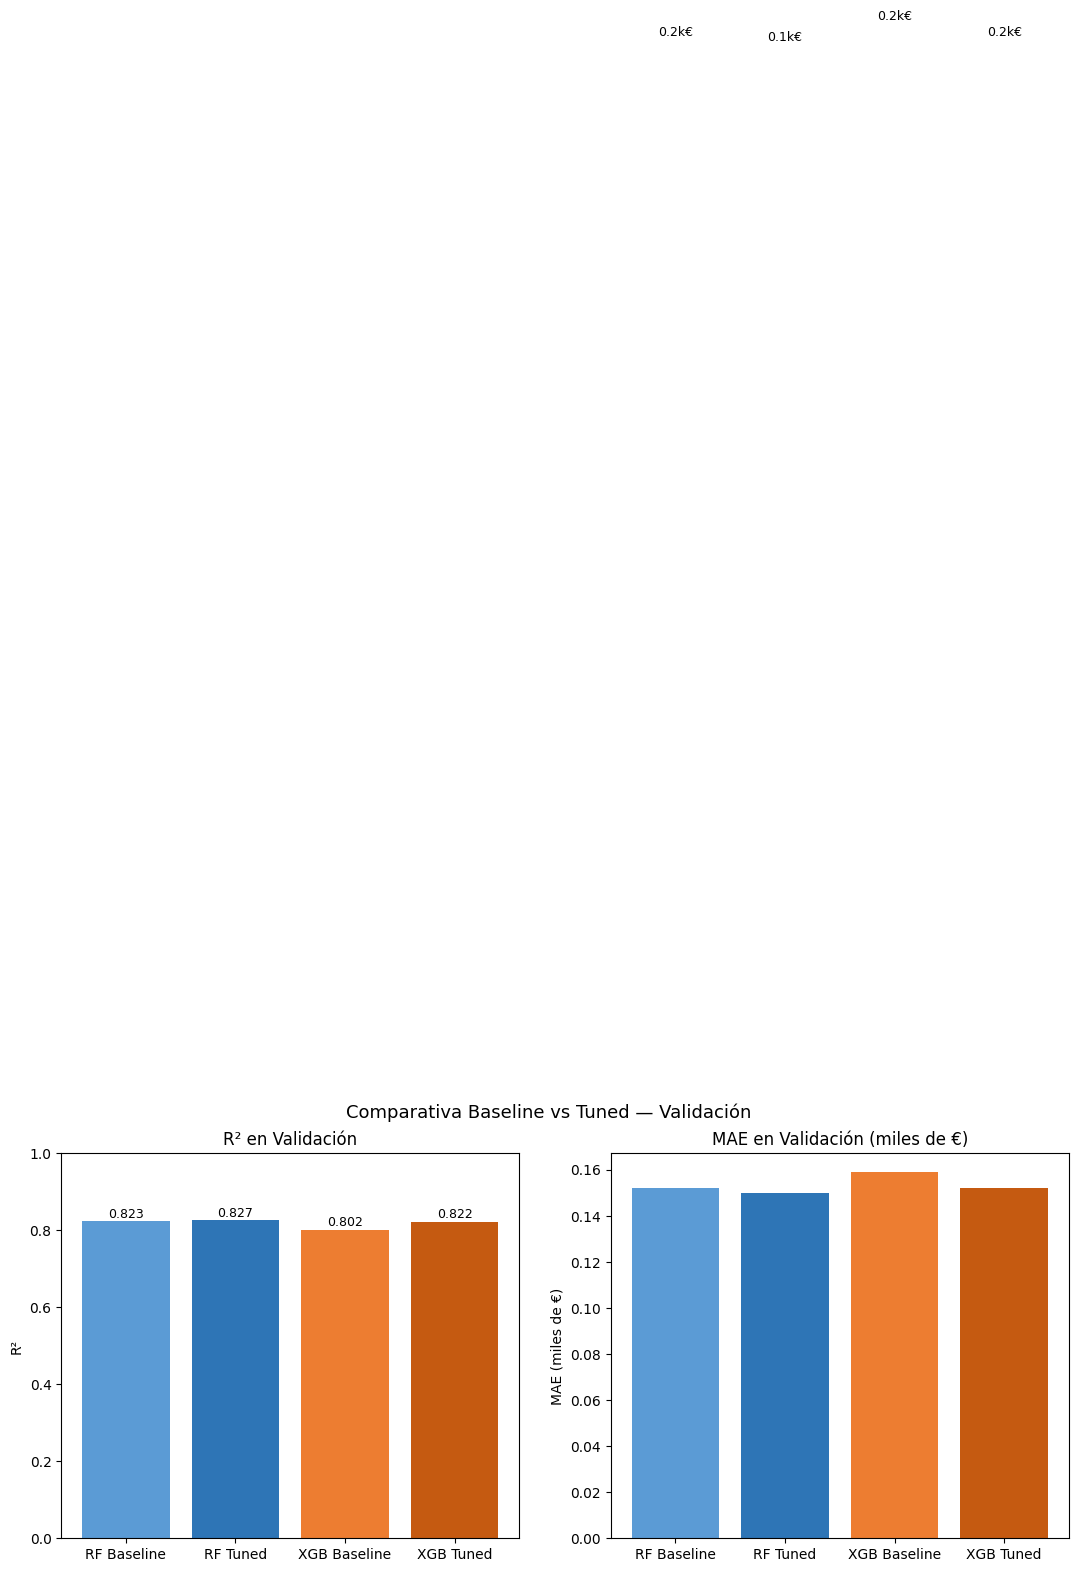

In [34]:
# Comparativa visual: baseline vs tuned
# Expresamos el MAE en miles de euros para que la escala del gráfico sea razonable
modelos  = ['RF Baseline', 'RF Tuned', 'XGB Baseline', 'XGB Tuned']
r2_vals  = [metricas_rf_base['R2'],       metricas_rf_tuned['R2'],
            metricas_xgb_base['R2'],      metricas_xgb_tuned['R2']]
mae_vals = [metricas_rf_base['MAE']/1000, metricas_rf_tuned['MAE']/1000,
            metricas_xgb_base['MAE']/1000,metricas_xgb_tuned['MAE']/1000]  # <-- dividimos entre 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = ['#5b9bd5', '#2e75b6', '#ed7d31', '#c55a11']

axes[0].bar(modelos, r2_vals, color=colores)
axes[0].set_title('R² en Validación')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(modelos, mae_vals, color=colores)
axes[1].set_title('MAE en Validación (miles de €)')  # <-- título actualizado
axes[1].set_ylabel('MAE (miles de €)')               # <-- eje actualizado
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + 0.5, f'{v:,.1f}k€', ha='center', fontsize=9)  # <-- etiquetas actualizadas

plt.suptitle('Comparativa Baseline vs Tuned — Validación', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Evaluación final en el conjunto de test

**Esta celda solo se ejecuta una vez, al final del proyecto.**  
El conjunto de test es completamente nuevo para el modelo y nos da una estimación **imparcial** del rendimiento real.  
Todas las decisiones de diseño y tuning se tomaron usando únicamente el conjunto de validación.

In [35]:
# Evaluación final — solo se mira el test UNA VEZ
print('RESULTADOS FINALES EN TEST:')
metricas_rf_test  = evaluar_modelo('Random Forest (test)', best_rf,  X_test, y_test)
metricas_xgb_test = evaluar_modelo('XGBoost (test)',       best_xgb, X_test, y_test)

RESULTADOS FINALES EN TEST:

=== Random Forest (test) ===
  MAE:  155.5176 €
  RMSE: 245.8203 €
  R²:   0.827022

=== XGBoost (test) ===
  MAE:  155.9566 €
  RMSE: 249.1816 €
  R²:   0.822260


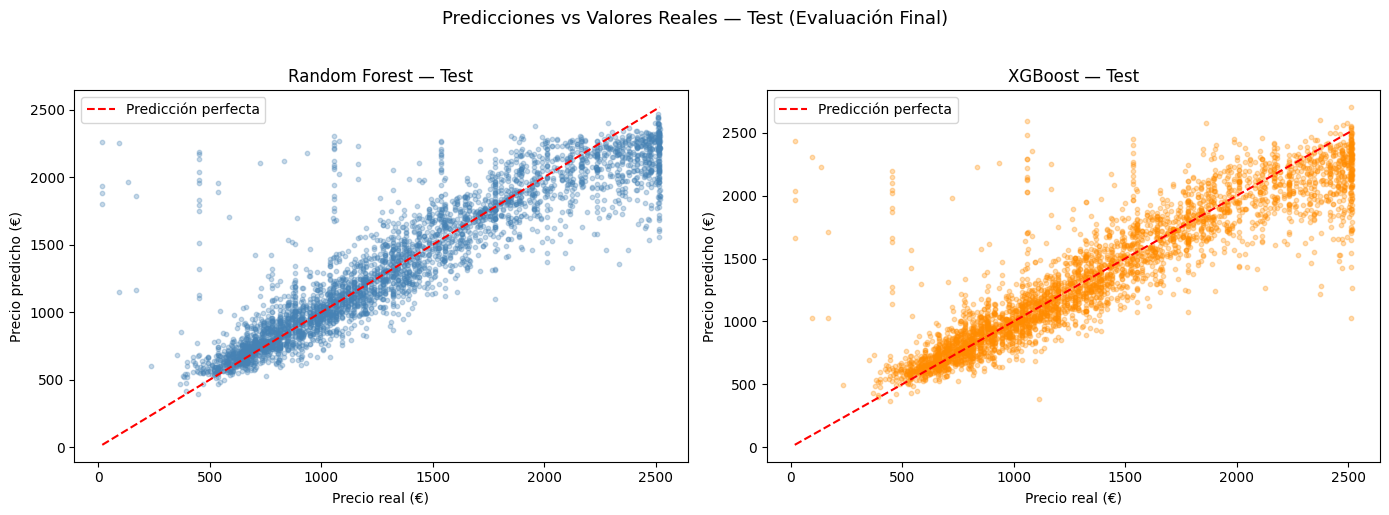

In [36]:
# Gráfico final: predicciones vs valores reales en test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, modelo, nombre, color in zip(
    axes,
    [best_rf, best_xgb],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'darkorange']
):
    preds = modelo.predict(X_test)
    ax.scatter(y_test, preds, alpha=0.3, s=10, color=color)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Precio real (€)')
    ax.set_ylabel('Precio predicho (€)')
    ax.set_title(f'{nombre} — Test')
    ax.legend()

plt.suptitle('Predicciones vs Valores Reales — Test (Evaluación Final)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Importancia de variables

Tanto Random Forest como XGBoost calculan la importancia de cada variable durante el entrenamiento.  
Esto nos permite entender qué características son más relevantes para predecir el precio de una vivienda.

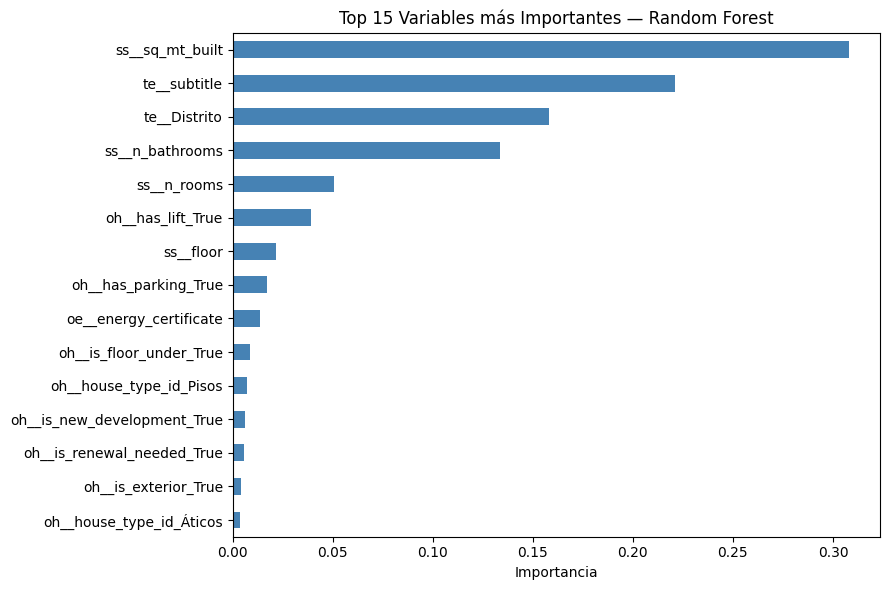

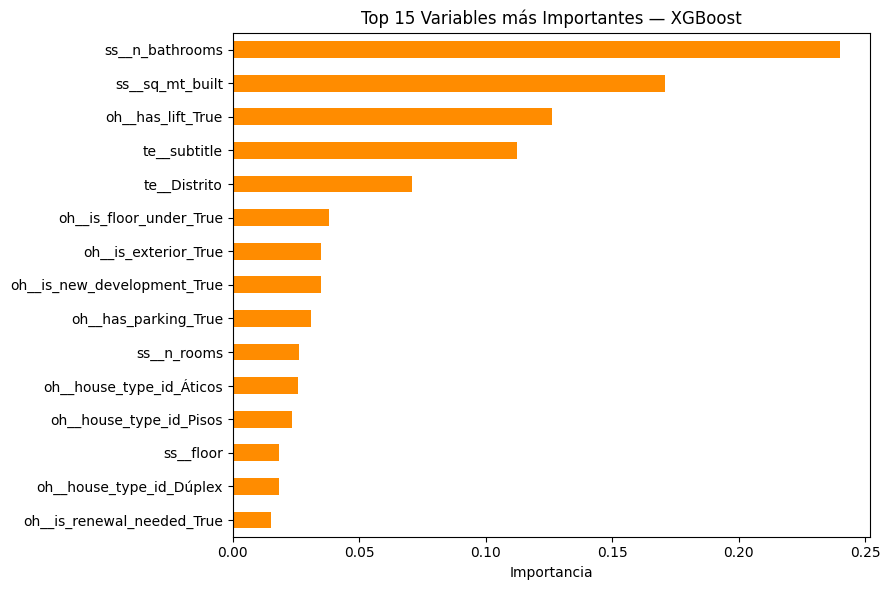

In [37]:
def plot_importancia(modelo, feature_names, titulo, color):
    """Visualiza las 15 variables más importantes de un modelo."""
    importancias = pd.Series(modelo.feature_importances_, index=feature_names)
    importancias = importancias.sort_values(ascending=True).tail(15)  # top 15

    plt.figure(figsize=(9, 6))
    importancias.plot(kind='barh', color=color)
    plt.title(f'Top 15 Variables más Importantes — {titulo}', fontsize=12)
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.show()

plot_importancia(best_rf,  X_train.columns, 'Random Forest', 'steelblue')
plot_importancia(best_xgb, X_train.columns, 'XGBoost',       'darkorange')

In [38]:
# Comparativa de importancias entre ambos modelos (top 10)
imp_rf  = pd.Series(best_rf.feature_importances_,  index=X_train.columns).sort_values(ascending=False).head(10)
imp_xgb = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

print('Top 10 variables — Random Forest:')
print(imp_rf.round(4).to_string())

print('\n Top 10 variables — XGBoost:')
print(imp_xgb.round(4).to_string())

Top 10 variables — Random Forest:
ss__sq_mt_built            0.3081
te__subtitle               0.2209
te__Distrito               0.1578
ss__n_bathrooms            0.1337
ss__n_rooms                0.0506
oh__has_lift_True          0.0391
ss__floor                  0.0216
oh__has_parking_True       0.0170
oe__energy_certificate     0.0135
oh__is_floor_under_True    0.0086

 Top 10 variables — XGBoost:
ss__n_bathrooms                0.2401
ss__sq_mt_built                0.1709
oh__has_lift_True              0.1263
te__subtitle                   0.1125
te__Distrito                   0.0708
oh__is_floor_under_True        0.0379
oh__is_exterior_True           0.0351
oh__is_new_development_True    0.0347
oh__has_parking_True           0.0308
ss__n_rooms                    0.0263


---
## 10. Resumen de resultados

Tabla comparativa final con los resultados de ambos modelos en validación y test.

In [39]:
# Tabla resumen de métricas
resumen = pd.DataFrame({
    'Modelo':    ['Random Forest', 'XGBoost'],
    'MAE Val (€)':  [round(metricas_rf_tuned['MAE'],  0), round(metricas_xgb_tuned['MAE'],  0)],
    'RMSE Val (€)': [round(metricas_rf_tuned['RMSE'], 0), round(metricas_xgb_tuned['RMSE'], 0)],
    'R² Val':       [round(metricas_rf_tuned['R2'],   4), round(metricas_xgb_tuned['R2'],   4)],
    'MAE Test (€)': [round(metricas_rf_test['MAE'],   0), round(metricas_xgb_test['MAE'],   0)],
    'RMSE Test (€)':[round(metricas_rf_test['RMSE'],  0), round(metricas_xgb_test['RMSE'],  0)],
    'R² Test':      [round(metricas_rf_test['R2'],    4), round(metricas_xgb_test['R2'],    4)],
})

print('📋 TABLA RESUMEN FINAL')
print('=' * 70)
print(resumen.to_string(index=False))
print('=' * 70)
print('\n Interpretación:')
print('  - MAE: error medio en euros (menor = mejor)')
print('  - RMSE: penaliza errores grandes (menor = mejor)')
print('  - R²: varianza explicada — 1.0 sería predicción perfecta (mayor = mejor)')

📋 TABLA RESUMEN FINAL
       Modelo  MAE Val (€)  RMSE Val (€)  R² Val  MAE Test (€)  RMSE Test (€)  R² Test
Random Forest        150.0         246.0  0.8266         156.0          246.0   0.8270
      XGBoost        152.0         249.0  0.8220         156.0          249.0   0.8223

 Interpretación:
  - MAE: error medio en euros (menor = mejor)
  - RMSE: penaliza errores grandes (menor = mejor)
  - R²: varianza explicada — 1.0 sería predicción perfecta (mayor = mejor)


In [40]:
record = pd.read_csv("../models/models_log.csv")
buy_r2 = record.loc[record["model"] == "rent_model", "r2"]
record_r2_log = 0 if buy_r2.empty or buy_r2.isna().all() else buy_r2.max()
print(record_r2_log)

0.7671365737915039


In [41]:
import joblib

best_params = {}
best_r2 = 0
best_mae = 0
model = None

# Se selecciona el mejor modelo en función del r2
if metricas_rf_tuned["R2"] >= metricas_xgb_tuned["R2"]:
    model = best_rf
    model_type = "rent_model_rf",
    model_name = "rent_model_ML.joblib"
    best_params = rf_search.best_params_
    best_r2 = metricas_rf_tuned["R2"]
    best_mae = metricas_rf_tuned["MAE"]

else:
    model = best_xgb
    model_type = "rent_model_xgboost"
    model_name = "rent_model_ML.joblib"
    best_params = xgb_search.best_params_
    best_r2 = metricas_xgb_tuned["R2"]
    best_mae = metricas_xgb_tuned["MAE"]

if best_r2 > record_r2_log:
    entry = {
        "model": "rent_model",
        "model_type": model_type,
        "model_name": model_name,
        "r2": best_r2,
        "mae": best_mae,
    }

    entry_df = pd.DataFrame(entry, index=[0])
    params_str = str(best_params)
    entry_df["params"] = params_str

    new_record = pd.concat([record, entry_df], ignore_index=True)

    new_record.to_csv("../models/models_log.csv", index=False)
    joblib.dump(model, f"../models/{model_name}", compress=7)

else:
    print("No se mejoró el modelo. No se guardará.")